In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
X, y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [3]:
df=pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

In [4]:
df


,Feature 1,Feature 2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324
...,...,...
495,-6.040014,-6.325329
496,-2.555459,9.218977
497,4.438408,2.974583
498,-7.193261,-6.250704


In [5]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(df)

In [6]:
inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

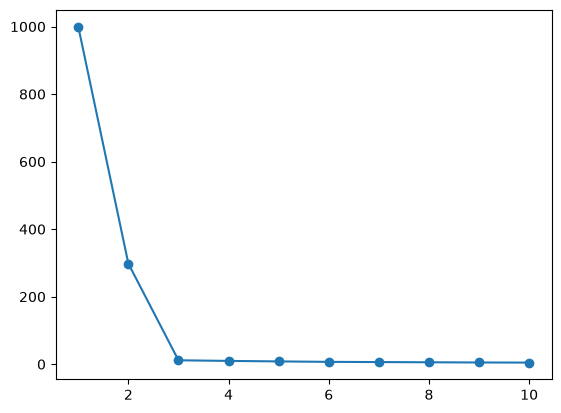

In [8]:
plt.plot(range(1, 11), inertia, marker='o')

In [9]:
k_final = 3
kmeans_final = KMeans(n_clusters=k_final, random_state=42)


In [10]:
cluster_labels = kmeans_final.fit_predict(X_scaled)

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

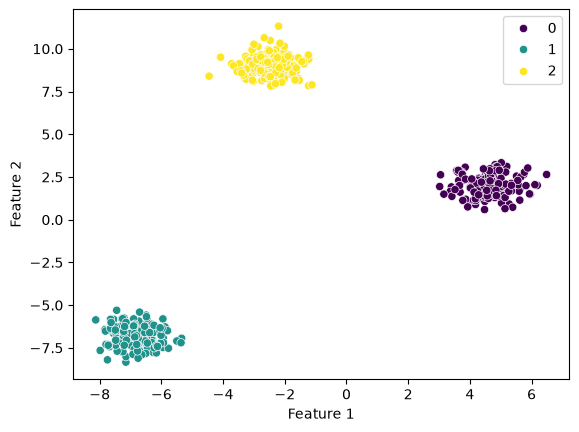

In [11]:
sns.scatterplot(x='Feature 1', y='Feature 2', hue=cluster_labels, palette='viridis', data=df)

In [12]:
from sklearn.datasets import make_moons 

In [13]:
X,y_true=make_moons(n_samples=500, noise=0.05, random_state=42)

In [14]:
from sklearn.cluster import DBSCAN

In [15]:
moons_df=pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])

In [16]:
scaller=StandardScaler()
X_scaled_moons=scaller.fit_transform(moons_df)

In [17]:
kmeans_moons = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans_moons.fit_predict(X_scaled_moons)

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

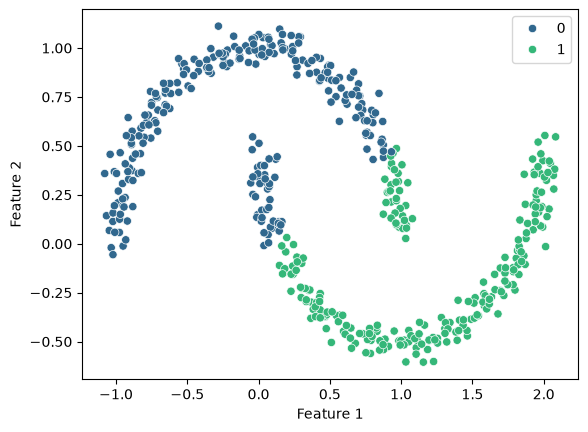

In [20]:
sns.scatterplot(x='Feature 1', y='Feature 2', hue=kmeans_labels, palette='viridis', data=moons_df)

In [21]:
DBSCAN_moons = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = DBSCAN_moons.fit_predict(X_scaled_moons)

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

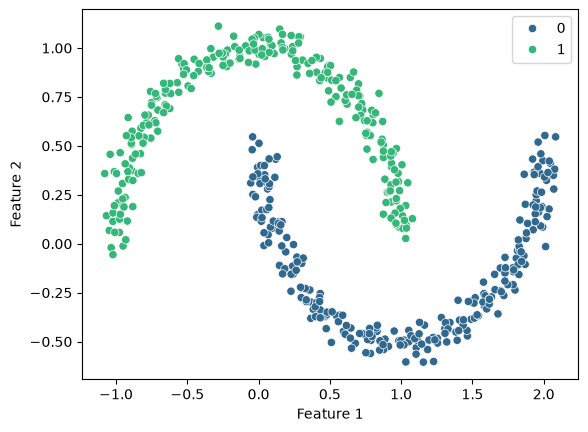

In [22]:
sns.scatterplot(x='Feature 1', y='Feature 2', hue=dbscan_labels, palette='viridis', data=moons_df)

# PCA

In [36]:
X,y = make_blobs(n_samples=500,n_features=5, centers=3,cluster_std=1.5, random_state=42)

In [37]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [38]:
pca=PCA(n_components=2)
X_pca=pca.fit_transform(X_scaled)

In [39]:
df_pca=pd.DataFrame(X_pca, columns=['PC1', 'PC2'])  
df_pca['label'] = y


<Axes: xlabel='PC1', ylabel='PC2'>

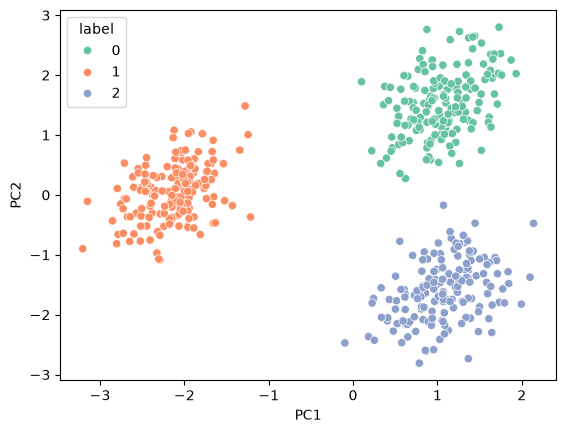

In [41]:
sns.scatterplot(x='PC1', y='PC2', hue='label', palette='Set2', data=df_pca)